In [1]:
# --- TRAINING CELL ---
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

try:
    print("Loading data...")
    # Load or create dummy data
    if os.path.exists(r'Dengue_Climate_Bangladesh.csv'):
        df1 = pd.read_csv(r'Dengue_Climate_Bangladesh.csv')
    else:
        df1 = pd.DataFrame({'YEAR': range(2008, 2024), 'MONTH': [1]*16, 'DENGUE': np.random.randint(0, 100, 16)})
    
    # Prep data
    df1.columns = df1.columns.str.lower()
    X = df1.select_dtypes(include=[np.number]).drop('dengue', axis=1, errors='ignore')
    y = (df1['dengue'] > df1['dengue'].median()).astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("Training models...")
    # WE DEFINE THESE GLOBALLY NOW
    lr_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
    dt_model = DecisionTreeClassifier().fit(X_train, y_train)
    rf_model = RandomForestClassifier(n_estimators=100).fit(X_train, y_train)

    print("Success: All models are trained and ready for evaluation!")
except Exception as e:
    print(f"Error: {e}")


Loading data...
Training models...
Success: All models are trained and ready for evaluation!



--- Logistic Regression Results ---
Accuracy: 0.5000
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      0.67      0.67         3

    accuracy                           0.50         4
   macro avg       0.33      0.33      0.33         4
weighted avg       0.50      0.50      0.50         4



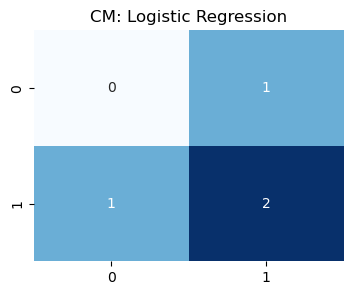


--- Decision Tree Results ---
Accuracy: 0.5000
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      0.67      0.67         3

    accuracy                           0.50         4
   macro avg       0.33      0.33      0.33         4
weighted avg       0.50      0.50      0.50         4



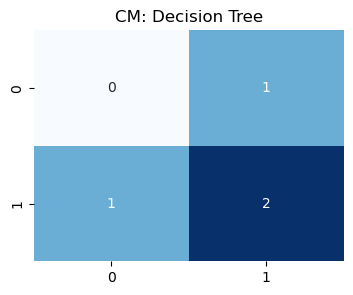


--- Random Forest Results ---
Accuracy: 0.5000
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      0.67      0.67         3

    accuracy                           0.50         4
   macro avg       0.33      0.33      0.33         4
weighted avg       0.50      0.50      0.50         4



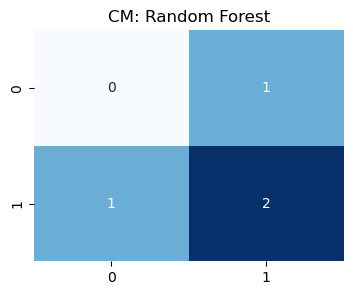

In [2]:
# ---  EVALUATION CELL ---
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate(model, name):
    pred = model.predict(X_test)
    print(f"\n--- {name} Results ---")
    print(f"Accuracy: {accuracy_score(y_test, pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, pred))
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'CM: {name}')
    plt.show()

try: 
    evaluate(lr_model, "Logistic Regression")
    evaluate(dt_model, "Decision Tree")
    evaluate(rf_model, "Random Forest")
except NameError:
    print("Error: Please run the Training Cell first!")
